In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Domain & Period

In [2]:
iyear=2000
fyear=2024
nx=10;ny=10
dom='GRq'
dom_NST = 'GRc'
year_NST = '2000'

# Elevation data

In [3]:
ds_grM= xr.open_dataset(f'/home/santolam/NST.{year_NST}.01.01.00.{dom_NST}.nc')
LONS=ds_grM.LON[ny:-ny,nx:-nx].values
LATS=ds_grM.LAT[ny:-ny,nx:-nx].values
dsSH=ds_grM.SH[ny:-ny,nx:-nx]
latS=LATS.min(); latN=LATS.max()
lonW=LONS.min(); lonE=LONS.max()

elev = dsSH

# Seasonal Mean data

In [4]:
TTZ = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TTZ_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TTZ'][:,0,:,:] # 0 = first pressure level at surface

#Domain & period def
TTZ = TTZ.rename({'TIME': 'time'})
TTZ = TTZ[:,ny:-ny,nx:-nx].sel(time=slice(str(iyear),str(fyear)))

In [5]:
seasons = ["DJFM","AM","JJAS","ON"]

tp_dict = {}

for season in seasons:
    tp_season = clim(TTZ, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp_dict[season] = tp_season

25


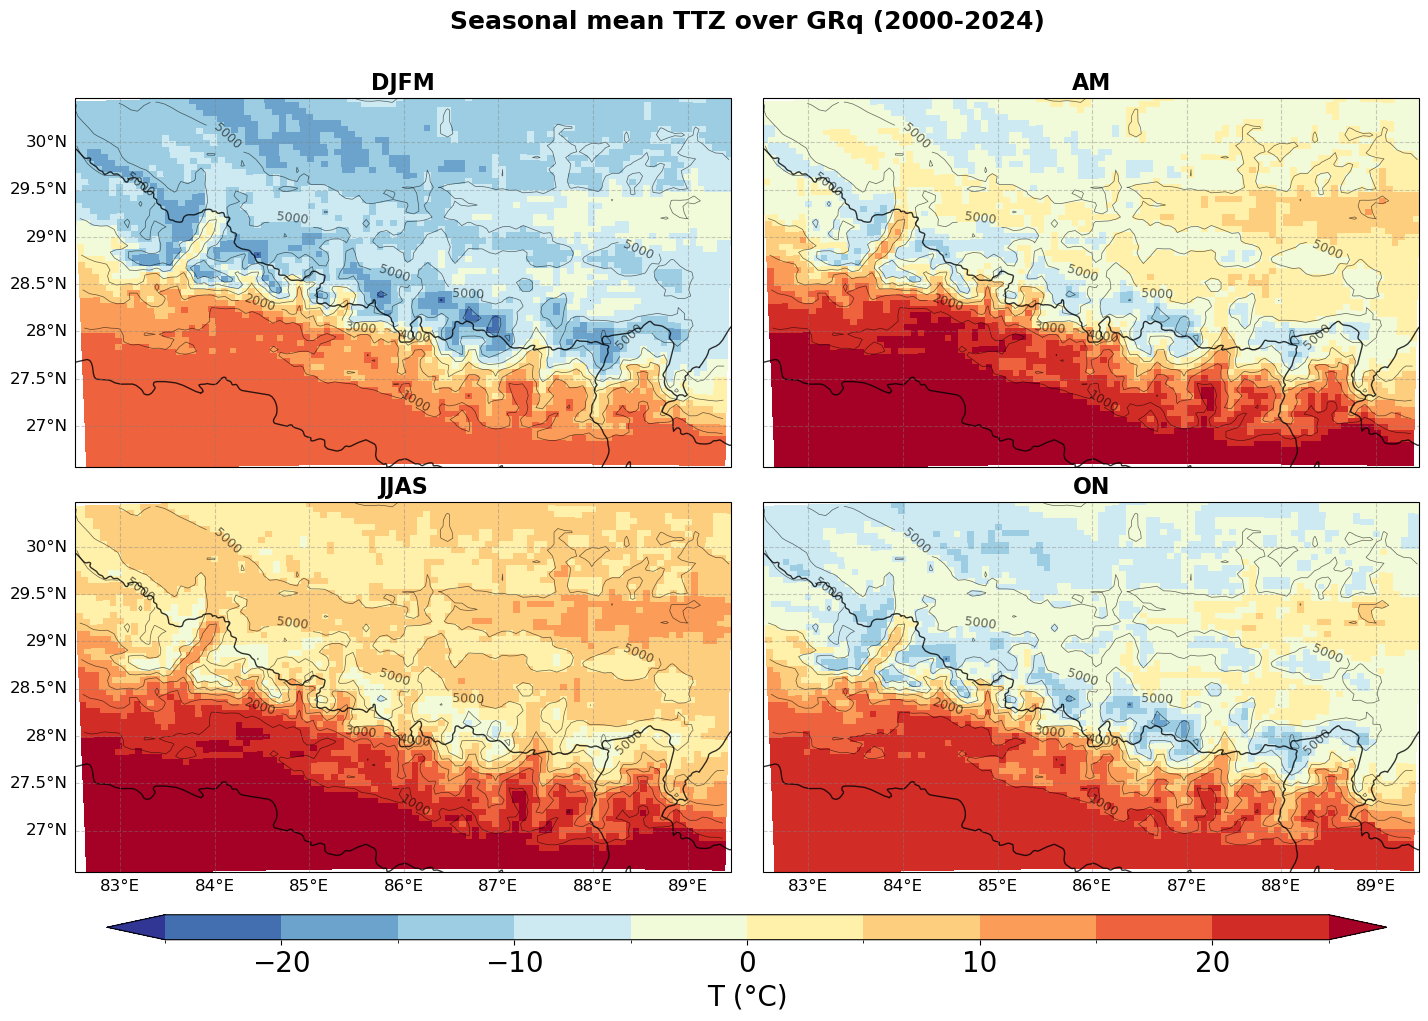

In [6]:
#==================== Color grading ============================

step = 5
vmax = 25
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdYlBu_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]
       
    im = ax.pcolormesh(
           LONS, LATS, data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
        
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        LONS,
        LATS,
        elev,
        levels=[1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.5,
        alpha=0.6,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("T (°C)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal mean TTZ over {dom} ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Seasonal Trends data

In [7]:
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

trend_dict = {}
p_dict={}

for season in seasons:
    tp_season = seasonal_selection2(TTZ, seasons[season], iyear, fyear)
    tp_season = tp_season.compute()
    par = trend_vect(tp_season.time, tp_season, dim='time')
    trend=par[0]*10; p=par[3]
    trend_dict[season]=trend
    p_dict[season]=p

1


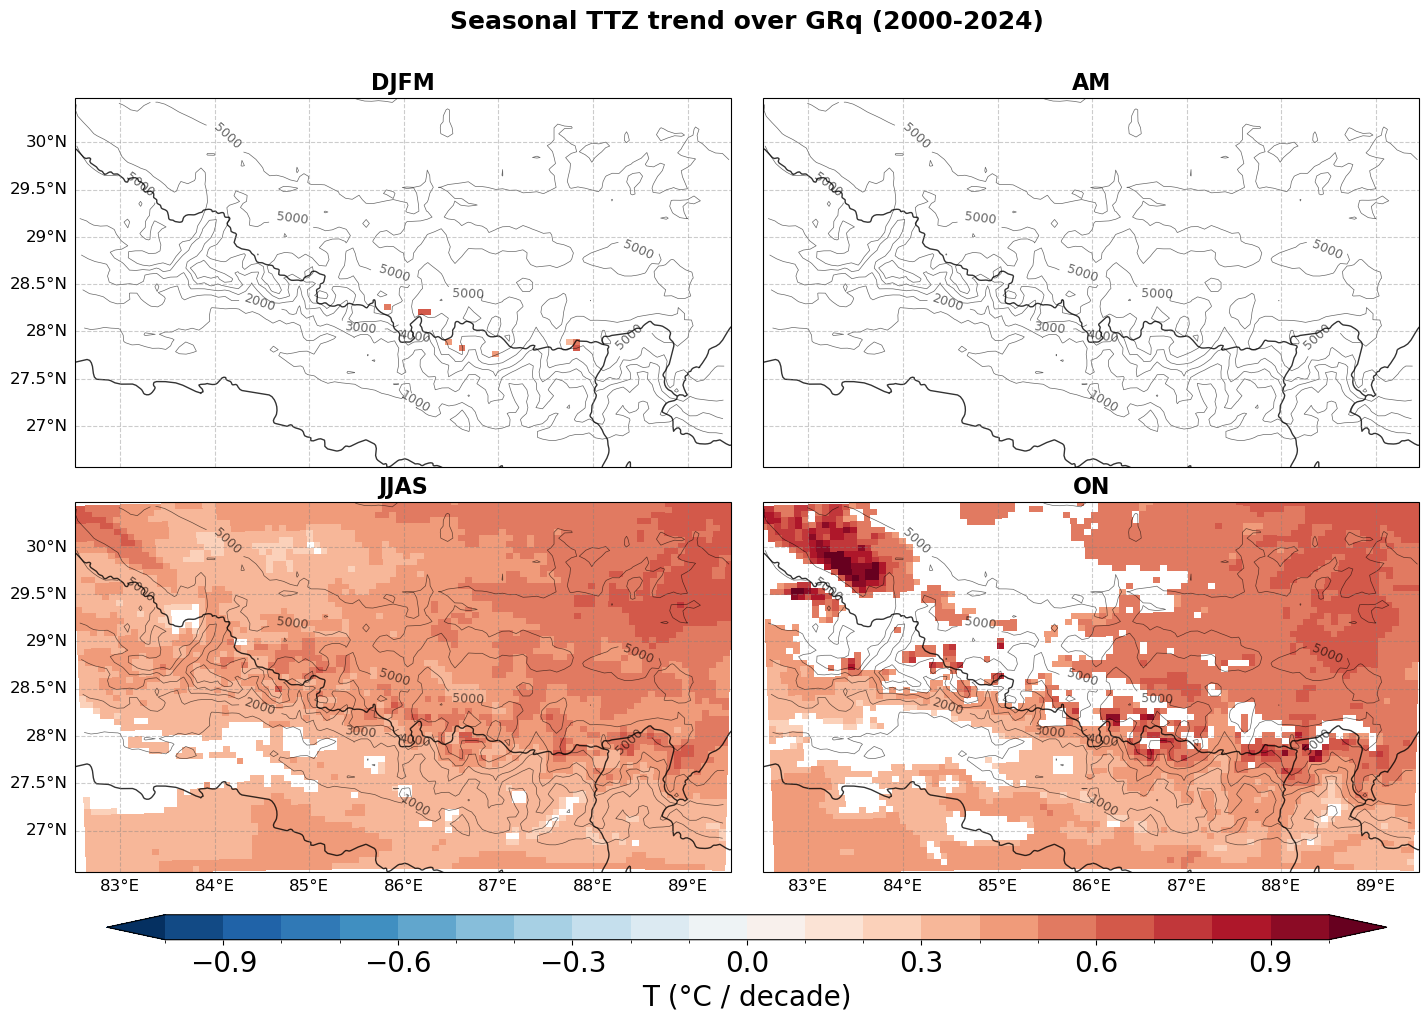

In [8]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 0.1
vmax = 1
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_dict[season]

    # Masque blanc pour zones non significatives
    sig = p_dict[season] < 0.05  # True = significatif
    
    # Crée une copie pour le plot avec NaN pour non significatif
    data_plot = data_model.where(sig)
    
    im = ax.pcolormesh(
           LONS, LATS, data_plot,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        LONS,
        LATS,
        elev,
        levels=[1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.5,
        alpha=0.6,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("T (°C / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal TTZ trend over {dom} ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

1


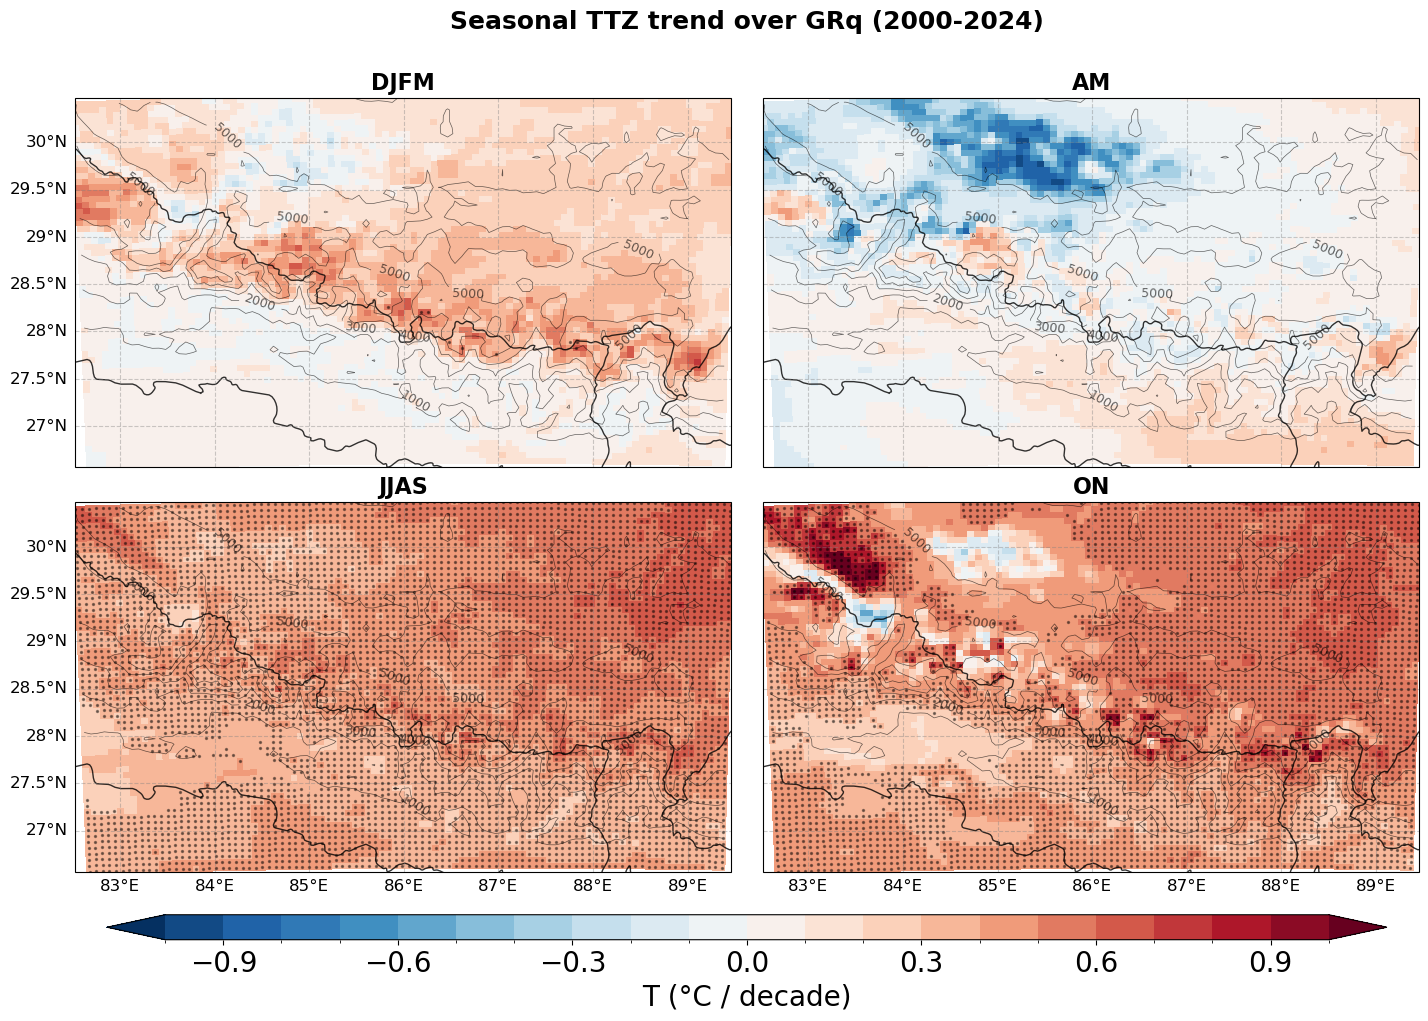

In [9]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 0.1
vmax = 1
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
cmap = cmap.copy()         # permet de modifier
cmap.set_bad(color='white')  # les NaN apparaissent en blanc
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_dict[season]
    
    im = ax.pcolormesh(
           LONS, LATS, data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )

    sig = p_dict[season] < 0.05   
    step = 1
    mask = sig.values

    ax.scatter(
        LONS[mask],
        LATS[mask],
        color='black', s=2,
        transform=ccrs.PlateCarree(),
        zorder=5, alpha=0.4
    )
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        LONS,
        LATS,
        elev,
        levels=[1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.5,
        alpha=0.6,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("T (°C / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.2)
plt.suptitle(
    f"Seasonal TTZ trend over {dom} ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()